# 경제국면 자산배분 — 무레버리지 동적 위험회피 수정안

이 노트북은 업로드한 `economic_regime_asset_allocation_backtest_multi_asset.ipynb`
의 피드백 적용본이다. 원본의 Hard regime 목표비중을 제거하고, soft 거시국면과
VKOSPI/VIX6 조건부 모멘트를 사용하는 SLSQP가 최종 비중 100%를 결정한다.

핵심 조건:

- 주식·채권·금·원유 비중합 100%
- 현금과 차입 없음
- volatility multiplier 없음
- 자산별 상한 없음: 각 자산 0~100%
- `lambda_t = 1 + stress_t`
- ex-ante 연변동성 13%, CDaR 16% 비상 제약

## 왜 `RiskScale`을 쓰지 않는가

현금이 없는 완전투자 포트폴리오에서 모든 자산에 같은 `k < 1`을 곱한 뒤
합계 100%로 재정규화하면 원래 비중으로 돌아온다.

\[
rac{k w_i}{\sum_j k w_j}=w_i
\]

따라서 위험할 때 총 익스포저를 70%로 줄이는 방식은 현금 자산이 있을 때만
성립한다. 여기서는 총 익스포저를 항상 100%로 유지하고 SLSQP가 채권·금 등으로
자산 구성을 바꾸게 한다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "strategies" / "core" / "regime_research.py").exists():
            return candidate
    raise FileNotFoundError(
        "RegimeDecisionTest 프로젝트 안에서 실행하거나 프로젝트 폴더를 먼저 업로드하세요."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: D:\Programming\python_example\RegimeDecisionTest


## 모듈과 경제적 설정

숫자 조합을 탐색하지 않는다. `lambda_0=1`, `alpha=1`은 0~1 스트레스
percentile이 최대일 때 하방위험 회피를 두 배로 만든다. 자산별 상한은 없다.

In [2]:
from strategies.stage14_unconstrained_dynamic_risk_slsqp.dynamic_risk_slsqp import (
    ASSETS,
    CATASTROPHE_ANNUAL_VOLATILITY,
    CATASTROPHE_CDAR,
    DYNAMIC_RISK_POLICY,
    STATIC_RISK_POLICY,
    UNCONSTRAINED_LONG_ONLY_BOUNDS,
    run_research,
)

print("Assets:", ASSETS)
print("Bounds:", UNCONSTRAINED_LONG_ONLY_BOUNDS)
print("Volatility guard:", CATASTROPHE_ANNUAL_VOLATILITY)
print("CDaR guard:", CATASTROPHE_CDAR)
print("Dynamic lambda at stress 0/0.5/1:", [
    DYNAMIC_RISK_POLICY.risk_aversion(value) for value in (0.0, 0.5, 1.0)
])

Assets: ['KODEX200', 'BOND', 'GLD', 'USO']
Bounds: [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]
Volatility guard: 0.13
CDaR guard: 0.16
Dynamic lambda at stress 0/0.5/1: [1.0, 1.5, 2.0]


## 전체 워크포워드 실행

매월 투자월보다 앞선 거시·옵션 신호와 수익률만 사용한다. 고정 lambda와 동적
lambda를 모두 계산해 동적 위험회피의 증분효과를 분리한다.

In [3]:
research = run_research(save=True)
comparison = research["comparison"]
display(comparison)

C:\Users\PC_1M\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Strategy,Period,Start,End,Months,CAGR,Volatility,Sharpe,Sortino,MDD,Calmar,FinalMultiple,PositiveMonths,AvgTurnover,TotalCost
0,Stage10_Original,full_2007_2026,2007-04,2026-07,232.0,0.068585,0.050998,1.329326,3.141403,-0.068783,0.997123,3.605597,0.698276,0.030547,0.021985
1,Stage13_50pctCap,full_2007_2026,2007-04,2026-07,232.0,0.115018,0.130690,0.900892,1.659295,-0.213193,0.539505,8.205776,0.607759,0.026998,0.018872
2,Stage14_NoAssetCap_StaticLambda,full_2007_2026,2007-04,2026-07,232.0,0.110041,0.133417,0.851191,1.571264,-0.231921,0.474477,7.525838,0.603448,0.029809,0.020919
3,Stage14_NoAssetCap_DynamicLambda,full_2007_2026,2007-04,2026-07,232.0,0.107584,0.131290,0.845965,1.547185,-0.229738,0.468291,7.210228,0.603448,0.029001,0.020326
4,Stage10_Original,locked_2018_2026,2018-01,2026-07,103.0,0.069854,0.058947,1.177322,2.826073,-0.068783,1.015572,1.785265,0.640777,0.037933,0.013033
5,Stage13_50pctCap,locked_2018_2026,2018-01,2026-07,103.0,0.162856,0.144924,1.117532,2.334311,-0.158980,1.024381,3.651149,0.621359,0.013877,0.004712
6,Stage14_NoAssetCap_StaticLambda,locked_2018_2026,2018-01,2026-07,103.0,0.161276,0.142741,1.122949,2.328988,-0.158980,1.014446,3.608801,0.611650,0.012826,0.004379
7,Stage14_NoAssetCap_DynamicLambda,locked_2018_2026,2018-01,2026-07,103.0,0.157796,0.138740,1.129679,2.312752,-0.158980,0.992555,3.517021,0.621359,0.011711,0.004013


## 단일자산 집중도와 solver 검증

In [4]:
report = research["report"]
concentration = pd.DataFrame({
    "static_lambda": report["static_lambda_concentration"],
    "dynamic_lambda": report["dynamic_lambda_concentration"],
}).loc[
    [
        "months_above_50_percent",
        "months_above_90_percent",
        "months_at_effective_100_percent",
        "maximum_single_asset_weight",
        "average_largest_weight",
    ]
]
display(concentration)
display(pd.DataFrame({
    "static": report["static_solver"],
    "dynamic": report["dynamic_solver"],
}))
assert all(report["checks"].values())
print("All causal, long-only, full-investment and no-leverage checks passed.")

,static_lambda,dynamic_lambda
months_above_50_percent,128,119
months_above_90_percent,2,2
months_at_effective_100_percent,0,0
maximum_single_asset_weight,0.995818,0.926913
average_largest_weight,0.518507,0.514593


,static,dynamic
months,2.320000e+02,2.320000e+02
successes,2.320000e+02,2.320000e+02
fallbacks,0.000000e+00,0.000000e+00
maximum_weight_sum_error,2.220446e-16,2.220446e-16
minimum_volatility_slack,-8.051526e-10,-8.181492e-10
minimum_cdar_slack,-9.872284e-10,-8.142153e-10
volatility_guard_binding_months,7.400000e+01,7.100000e+01
cdar_guard_binding_months,8.200000e+01,8.200000e+01


All causal, long-only, full-investment and no-leverage checks passed.


## 동적 위험회피 귀속

,months,overlay_cumulative_return,average_monthly_overlay_alpha,cagr_change,sharpe_change,mdd_change,risk_off_months,false_positive_months,crash_months,caught_crash_months,missed_crash_months,diagnostic_crash_threshold
full_2007_2026,232.0,-0.047386,-0.000208,-0.002457,-0.005226,2.183226e-03,192.0,110.0,24.0,18.0,6.0,-0.058896
locked_2018_2026,103.0,-0.030254,-0.000297,-0.003480,0.006729,2.511302e-11,89.0,48.0,11.0,8.0,3.0,-0.058838


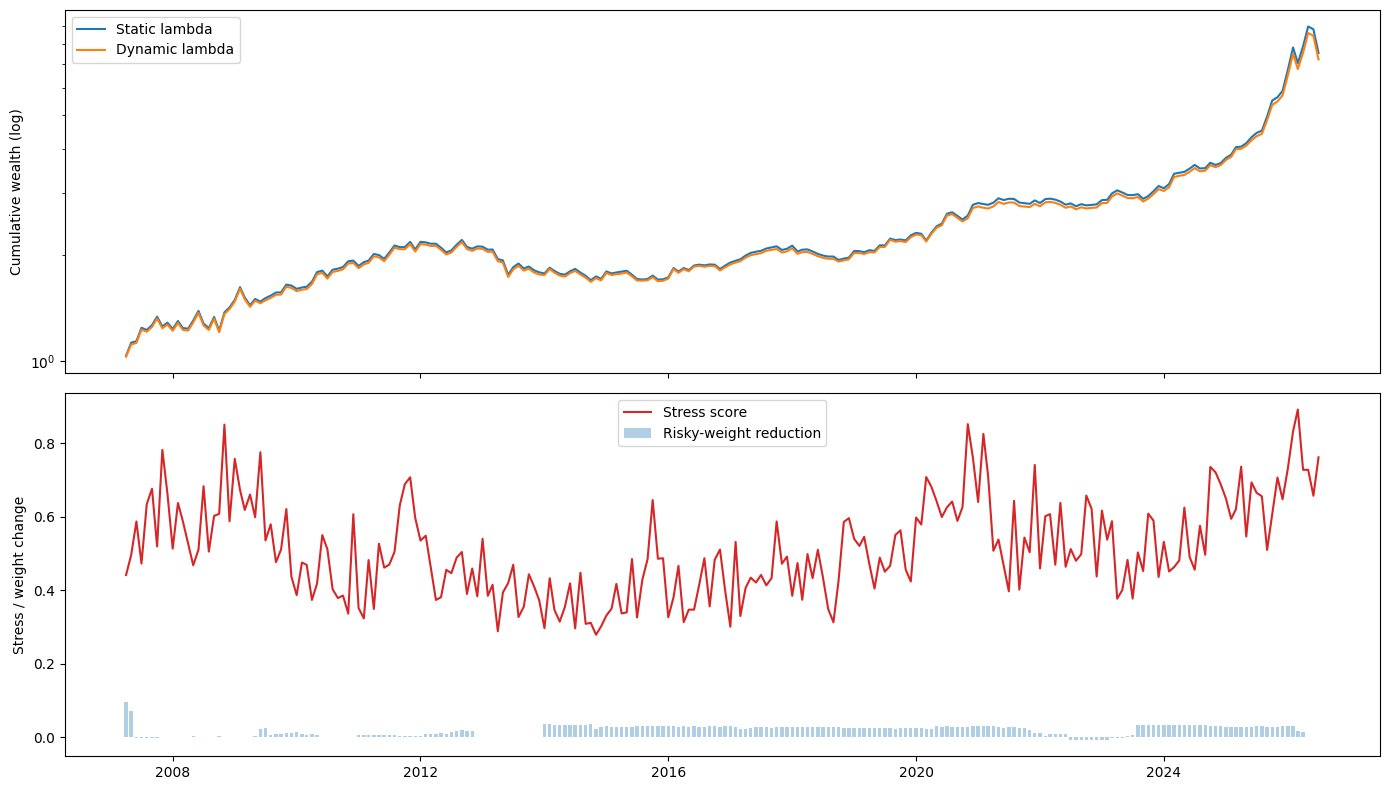

In [5]:
display(pd.DataFrame(report["dynamic_risk_attribution"]).T)

attribution = research["attribution"]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(
    attribution.index.to_timestamp(),
    (1 + attribution["return_base"]).cumprod(),
    label="Static lambda",
)
axes[0].plot(
    attribution.index.to_timestamp(),
    (1 + attribution["return_stress_aware"]).cumprod(),
    label="Dynamic lambda",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Cumulative wealth (log)")
axes[0].legend()

axes[1].plot(
    attribution.index.to_timestamp(),
    attribution["stress_score"],
    label="Stress score",
    color="tab:red",
)
axes[1].bar(
    attribution.index.to_timestamp(),
    attribution["risk_reduction"],
    width=20,
    alpha=0.35,
    label="Risky-weight reduction",
)
axes[1].set_ylabel("Stress / weight change")
axes[1].legend()
plt.tight_layout()
plt.show()

## 해석

전체기간에는 동적 lambda가 고정 lambda보다 CAGR을 약 0.25%p 낮추고 MDD를
약 0.22%p 개선했다. Sharpe는 소폭 낮아졌다. 2018년 이후에는 Sharpe와
실현 변동성이 개선됐지만 CAGR이 낮아졌고 MDD는 같았다.

또한 단일자산 상한을 없애자 Stage13보다 CAGR·Sharpe·MDD가 모두 나빠졌다.
따라서 이 구조는 요청한 제약을 정확히 구현한 연구 기준선이지, 자동으로 기존
전략을 대체하는 승격안은 아니다.